In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [178]:
data = r"..\data\processed\pypi_download_history_cleaned.csv"
df=pd.read_csv(data)

In [179]:
df.head()

,package_name,date,downloads
0,beautifulsoup4,2026-04-06,9385346
1,seaborn,2026-04-06,1508171
2,jupyterlab,2026-04-06,1574802
3,black,2026-04-06,3837760
4,rich,2026-04-06,14861178


In [180]:
df.dtypes

package_name      str
date              str
downloads       int64
dtype: object

In [181]:
df["date"]=pd.to_datetime(df["date"])

In [182]:
top_n_packages=10
top_packages=df.groupby("package_name")["downloads"].sum().sort_values(ascending=False).reset_index()
top_packages.head(top_n_packages)

,package_name,downloads
0,boto3,18672705302
1,requests,9200295442
2,pydantic,6024291771
3,numpy,5904803833
4,click,5799065894
5,pytest,5322089070
6,httpx,4300030829
7,rich,3373878745
8,uvicorn,3226517582
9,litellm,2842815981


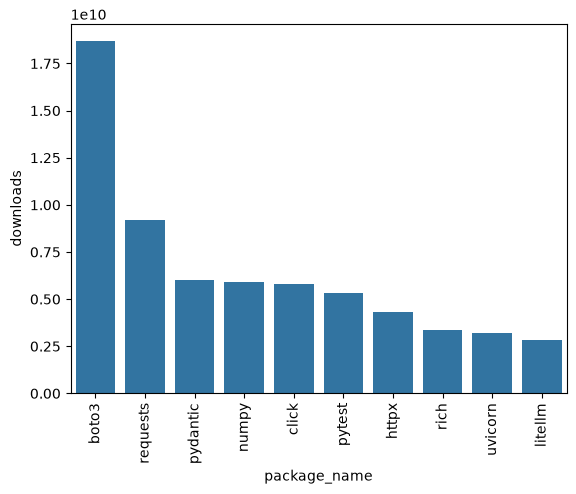

In [183]:
sns.barplot(data=top_packages.head(top_n_packages),x="package_name",y="downloads")
plt.xticks(rotation=90)
plt.show()

In [228]:
donut_data=top_packages.head(10).copy()
other_downloads=top_packages.iloc[10:].sum()
donut_data.loc[len(donut_data)] = ["other", other_downloads["downloads"]]
donut_data

,package_name,downloads
0,boto3,18672705302
1,requests,9200295442
2,pydantic,6024291771
3,numpy,5904803833
4,click,5799065894
5,pytest,5322089070
6,httpx,4300030829
7,rich,3373878745
8,uvicorn,3226517582
9,litellm,2842815981


In [233]:
package_name = list(donut_data["package_name"])
colors_11 = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    "#393b79",
]
package_name

['boto3',
 'requests',
 'pydantic',
 'numpy',
 'click',
 'pytest',
 'httpx',
 'rich',
 'uvicorn',
 'litellm',
 'other']

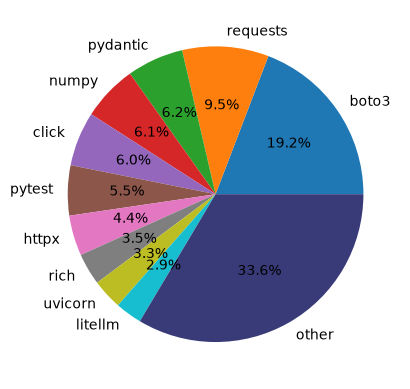

In [235]:
plt.pie(donut_data["downloads"],labels=package_name,autopct="%0.1f%%",colors=colors_11)
plt.show()

In [185]:
df["months"]=df["date"].dt.month_name()
df.head(1)

,package_name,date,downloads,months
0,beautifulsoup4,2026-04-06,9385346,April


In [ ]:
top_n=5
top_packages_list = list(top_packages["package_name"].values)[:top_n]
top_packages_list

['boto3', 'requests', 'pydantic', 'numpy', 'click']

In [187]:
top_downloads_over_time=df[df["package_name"].isin(top_packages_list)].groupby(["months","package_name"])['downloads'].sum().reset_index()
top_downloads_over_time

,months,package_name,downloads
0,April,boto3,2337992152
1,April,click,790518057
2,April,numpy,768247380
3,April,pydantic,815433437
4,April,requests,1258210282
5,August,boto3,3221807176
6,August,click,1090305356
7,August,numpy,1111695120
8,August,pydantic,1117953484
9,August,requests,1694439177


In [237]:
month_order = ["April", "May", "June", "July", "August", "September", "October"]
top_downloads_over_time["months"] = pd.Categorical(
    top_downloads_over_time["months"], categories=month_order, ordered=True
)
top_downloads_over_time = top_downloads_over_time.sort_values("months")
pivot_df = top_downloads_over_time.pivot(
    index="months", columns="package_name", values="downloads"
)
pivot_df


package_name,boto3,click,numpy,pydantic,requests
months,,,,,
April,2337992152,790518057,768247380,815433437,1258210282
May,3281155850,987526917,977059915,1058574318,1600926553
June,3573594234,997359025,1084121364,1057038017,1647111902
July,3715255664,1088503918,1137711486,1102195212,1750883315
August,3221807176,1090305356,1111695120,1117953484,1694439177
September,2455447260,810070226,793258595,838410099,1199537437
October,87452966,34782395,32709973,34687204,49186776


In [189]:
fig=px.line(top_downloads_over_time,x="months",y="downloads",color="package_name",markers=True)
fig.update_layout(
    xaxis_title="Months",
    yaxis_title="Downloads",
    template="plotly_white",
)
fig.show()

In [240]:
downloads_over_months=df.groupby("months")["downloads"].sum().sort_values(ascending=False).reset_index()
month_order = ["April", "May", "June", "July", "August", "September", "October"]
downloads_over_months["months"] = pd.Categorical(
    downloads_over_months["months"], categories=month_order, ordered=True
)
downloads_over_months = downloads_over_months.sort_values("months")
downloads_over_months

,months,downloads
5,April,12593112268
3,May,16482629803
2,June,17840080948
0,July,18849372483
1,August,18161714775
4,September,12873479546
6,October,519696569


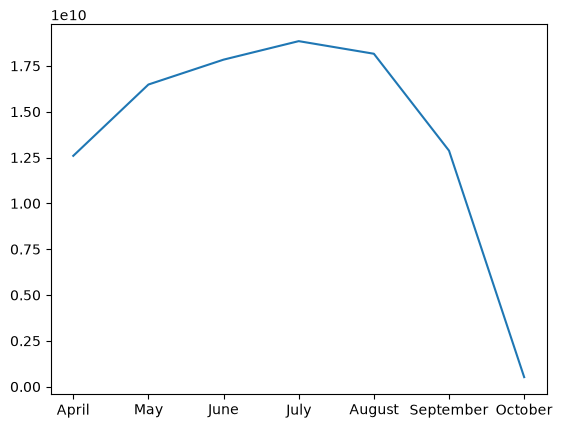

In [242]:
plt.plot(downloads_over_months["months"],downloads_over_months["downloads"])
plt.show()